In [2]:
import torch
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [4]:
#load Sigma-Sampler
%run Sigma-Sampler.ipynb

In [6]:
#sample lognormal function
def sample_lognormal(mu, beta, N=100000):
    log_sigma = torch.randn(N) * beta + mu
    return log_sigma

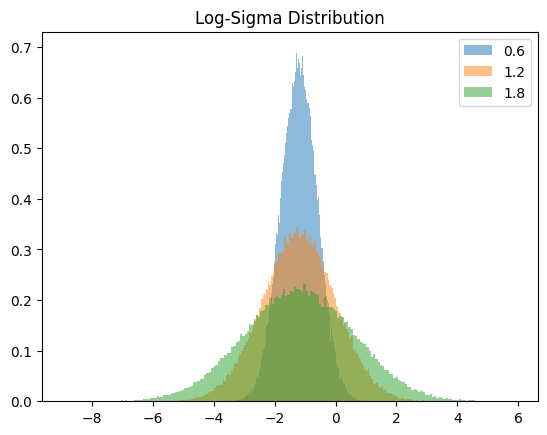

In [8]:
#show distribution of log sigma
mu = -1.2
for beta in [0.6, 1.2, 1.8]:
    #compute log sigma
    log_sigma = sample_lognormal(mu, beta)
    plt.hist(log_sigma.numpy(), bins=200, density=True, alpha=0.5)
plt.title('Log-Sigma Distribution')
plt.legend(['0.6', '1.2', '1.8'])
plt.show()

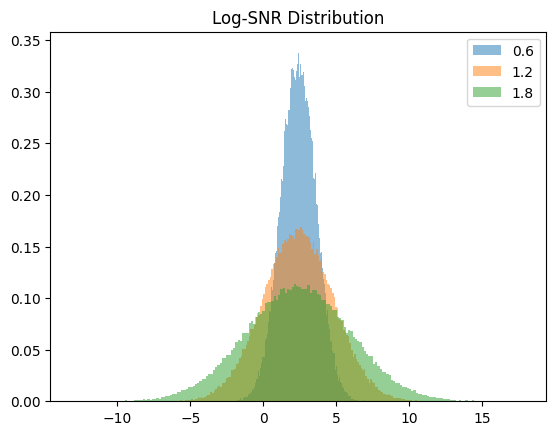

In [10]:
#show distribution of log snr
mu = -1.2
for beta in [0.6, 1.2, 1.8]:
    log_sigma = sample_lognormal(mu, beta)
    #compute log snr
    sigma = torch.exp(log_sigma)
    snr = 1 / sigma ** 2
    log_snr = torch.log(snr)
    plt.hist(log_snr.numpy(), bins=200, density=True, alpha=0.5)
plt.title('Log-SNR Distribution')
plt.legend(['0.6', '1.2', '1.8'])
plt.show()